<center><img src="https://github.com/DACSS-Spatial/data_forSpatial/raw/main/logo.png" width="700"></center>

<a target="_blank" href="https://colab.research.google.com/github/DACSS-Spatial/The-Thematics/blob/main/index.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# The Thematic map

Last session we created a file with several layers:

In [58]:
import geopandas as gpd
linkWorldMaps='https://github.com/DACSS-Spatial-Data-Class/Homework1/raw/refs/heads/main/worldMaps.gpkg'

We can easily find out the layers in that geopackage file (**worldMaps.gpkg**):

In [59]:
gpd.list_layers(linkWorldMaps)

,name,geometry_type
0,rivers,MultiLineString
1,cities,Point
2,countries,MultiPolygon


For the thematics we will retrieve only one layer (map):

In [57]:
countries=gpd.read_file(linkWorldMaps,layer='countries')

# see some
countries

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
...,...,...
247,South Sudan,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
248,Indonesia,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."
249,East Timor,"MULTIPOLYGON (((124.41824 -9.3001, 124.40446 -..."
250,Curacao (Netherlands),"MULTIPOLYGON (((-68.96556 12.19889, -68.91196 ..."


As you see, the GDF above has just two colums; enough to plot a map, but no more than that.

Let me open a DF:

In [60]:
import pandas as pd

someDataLink='https://github.com/DACSS-Spatial-Data-Class/Homework1/raw/refs/heads/main/some_dataworld.csv'

someData=pd.read_csv(someDataLink)

## data available
someData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       172 non-null    object 
 1   iso2          171 non-null    object 
 2   iso3          172 non-null    object 
 3   region        172 non-null    object 
 4   fragility     172 non-null    float64
 5   co2           172 non-null    int64  
 6   sq_km         172 non-null    int64  
 7   num_airports  172 non-null    int64  
 8   population    172 non-null    int64  
 9   mobiles       172 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 13.6+ KB


## Pre Processing: Merging

The DF has some interesting numerical data (_float64_):
* fragility: fragility index 2023 -[details here](https://fragilestatesindex.org/2023/06/14/fragile-states-index-2023-annual-report/)
* co2: metric tonnes of CO2 emmitted -[details here](https://www.cia.gov/the-world-factbook/field/carbon-dioxide-emissions/country-comparison/)
* sq_km: country area -[details here](https://www.cia.gov/the-world-factbook/field/area/country-comparison/)
* num_airports: count of airports in the country -[details here](https://www.cia.gov/the-world-factbook/field/airports/country-comparison/)
* population: country population  -[details here](https://www.cia.gov/the-world-factbook/field/population/country-comparison/)
* mobiles: total number of mobile cellular telephone subscribers -[details here](https://www.cia.gov/the-world-factbook/field/telephones-mobile-cellular/country-comparison/)

There are also other columns that may be of help:

In [61]:
someData.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000


Preparing thematic maps requires **social data** about the geometry (line, polygon, point). The "countries" geoDF has no social data, so the preprocessing requires merging the DF into the GDF.

Merging is not a trivial process. For this case, it will even require fuzzy merging. You may see the full mergin process in this [GoogleColab notebook](https://colab.research.google.com/drive/1iGTr8z1Bo8sitgg7uNcKh33pwleymb8O?usp=sharing).

We will use the file produced by that colab notebook

In [62]:
import geopandas as gpd
linkToIndicators="https://github.com/DACSS-Spatial-Data-Class/Homework1/raw/refs/heads/main/worldindicators.json"
theMapAndData=gpd.read_file(linkToIndicators)
theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Country       172 non-null    object  
 1   iso2          171 non-null    object  
 2   iso3          172 non-null    object  
 3   region        172 non-null    object  
 4   fragility     172 non-null    float64 
 5   co2           172 non-null    int64   
 6   sq_km         172 non-null    int32   
 7   num_airports  172 non-null    int32   
 8   population    172 non-null    int32   
 9   mobiles       172 non-null    int32   
 10  geometry      172 non-null    geometry
dtypes: float64(1), geometry(1), int32(4), int64(1), object(4)
memory usage: 12.2+ KB


In [63]:
theMapAndData

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,geometry
0,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
1,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
3,AZERBAIJAN,AZ,AZE,MIDDLE EAST,73.2,35389000,86600,32,10650239,11000000,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
4,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000,"MULTIPOLYGON (((20.79192 40.43154, 20.78722 40..."
...,...,...,...,...,...,...,...,...,...,...,...
167,ZAMBIA,ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000,"MULTIPOLYGON (((30.21302 -14.98172, 30.21917 -..."
168,ZIMBABWE,ZW,ZWE,AFRICA,99.5,7902000,390757,144,17150352,15000000,"MULTIPOLYGON (((32.48888 -21.34445, 32.46541 -..."
169,SOUTH SUDAN,SS,SSD,AFRICA,112.2,1778000,644329,89,12703714,6170000,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
170,INDONESIA,ID,IDN,EAST AND SOUTHEAST ASIA,70.4,563543000,1904569,556,281562465,352000000,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."


As you see, the columns from the DF (someData) are now part of the GDF (countries), that is now in this new GDF **theMapAndData**.

# Thematics: the DDM (Dot Density Map)

You have a DDM if you use **dots** to show comparatively which polygon of a map has 'more' (or 'less') of some countable phenomenon of interest.
A dot is an aggregated value, but it is constant for each dot.

We have the world map, let's see the regions we have:

In [64]:
theMapAndData.region.value_counts()

,count
region,
AFRICA,52
EUROPE,37
MIDDLE EAST,16
CENTRAL AMERICA AND THE CARIBBEAN,16
EAST AND SOUTHEAST ASIA,15
SOUTH AMERICA,12
SOUTH ASIA,8
AUSTRALIA AND OCEANIA,7
CENTRAL ASIA,6


### Preprocessing: Filtering

Let's keep Africa for this session:

<Axes: >

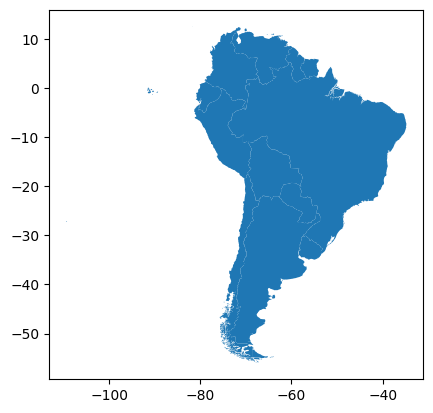

In [65]:
SAmerica=theMapAndData[theMapAndData.region=='SOUTH AMERICA']
SAmerica.plot()

**What variable to use?** Let's go with population (countable).

A DDM can serve as an effective way to show the distribution of people. The most critical tasks are:

* Unit per Dot: Deciding how many people each dot should represent is key for visual clarity. This value should be chosen carefully to avoid oversaturation or sparsity.

* Dot Placement: The dots should be randomly distributed within each polygon to avoid misrepresenting the data.

Every dot represents the same amount, then a DDM uses raw counts (non-normalized). The size of all dots on the map are the same, which  ensures a consistent visual comparison.

### Preprocessing: NEW UNIT

How many people will the dot represent? There is some **trial and error** to make this decision, but it helps exploring the variable descriptives.

In [66]:
print(SAmerica.mobiles.describe().to_string(float_format=lambda x: f'{x:.0f}'))

count          12
mean     41284583
std      60176428
min        856000
25%       7702500
50%      18500000
75%      46650000
max     213000000


From what we see, we should not choose 100 000 as the unit per dot. At least one country will have zero dots. Then, the trial and error is about choosing values like 1000, 10000, 20000, etc., but below 98187.

If we chose 25000, this would be the amount of points within each polygon (country):

In [67]:
(SAmerica.set_index("Country").mobiles / 20000).astype(int).sort_values()

,mobiles
Country,
GUYANA,42
SURINAME,49
URUGUAY,240
PARAGUAY,433
BOLIVIA,600
ECUADOR,910
VENEZUELA,940
CHILE,1335
PERU,2065


This is a safe option (no zeroes).

### Preprocessing: NEW LAYER

We need to create a map of dots, a new layer. The source will be the South America polygons we currently have. Let's do that first:

In [68]:
# a copy of SAmerica
temporal_gdf=SAmerica.copy()
temporal_gdf.head()

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,geometry
7,ARGENTINA,AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,"MULTIPOLYGON (((-71.01648 -36.47591, -70.98195..."
18,BOLIVIA,BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,"MULTIPOLYGON (((-62.19884 -20.47139, -62.26945..."
22,BRAZIL,BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,"MULTIPOLYGON (((-70.62862 -9.94849, -70.62889 ..."
34,CHILE,CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,"MULTIPOLYGON (((-73.61806 -51.6339, -73.60494 ..."
37,COLOMBIA,CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,"MULTIPOLYGON (((-81.71306 12.49028, -81.72014 ..."


the GeoDF **temporal_gdf** is just an independent copy of South America, as you see all the geometries are MULTIPOLYGONS still. Let me replace the row names by the country name:

In [69]:
# the row names will be the country
temporal_gdf.set_index('Country',inplace=True)

# we have this now
temporal_gdf.head()

,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,geometry
Country,,,,,,,,,,
ARGENTINA,AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,"MULTIPOLYGON (((-71.01648 -36.47591, -70.98195..."
BOLIVIA,BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,"MULTIPOLYGON (((-62.19884 -20.47139, -62.26945..."
BRAZIL,BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,"MULTIPOLYGON (((-70.62862 -9.94849, -70.62889 ..."
CHILE,CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,"MULTIPOLYGON (((-73.61806 -51.6339, -73.60494 ..."
COLOMBIA,CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,"MULTIPOLYGON (((-81.71306 12.49028, -81.72014 ..."


Let's create **dots_per_country**, the column that represents the amount of dots for each country (like we saw before):

In [70]:
# creating  column
temporal_gdf['dots_per_country'] = (SAmerica['mobiles'] / 20000).astype(int).values # notice .values!

# see
temporal_gdf['dots_per_country'].head(12)

,dots_per_country
Country,
ARGENTINA,3135
BOLIVIA,600
BRAZIL,10650
CHILE,1335
COLOMBIA,4370
ECUADOR,910
GUYANA,42
SURINAME,49
PARAGUAY,433


Let's find a **random_location** for the dots:

In [71]:
# enter 'sample_points()'
temporal_gdf.sample_points(size=temporal_gdf['dots_per_country'],rng=123).head(12)

,sampled_points
Country,
ARGENTINA,"MULTIPOINT ((-73.30253 -50.05253), (-73.20917 ..."
BOLIVIA,"MULTIPOINT ((-69.38526 -15.71373), (-69.33342 ..."
BRAZIL,"MULTIPOINT ((-73.80329 -7.43018), (-73.79706 -..."
CHILE,"MULTIPOINT ((-109.33975 -27.0844), (-75.52923 ..."
COLOMBIA,"MULTIPOINT ((-79.02123 1.64222), (-78.84972 1...."
ECUADOR,"MULTIPOINT ((-91.59549 -0.31294), (-91.55816 -..."
GUYANA,"MULTIPOINT ((-60.3444 5.31429), (-60.25068 5.3..."
SURINAME,"MULTIPOINT ((-57.74299 3.67456), (-57.41435 4...."
PARAGUAY,"MULTIPOINT ((-62.2501 -20.57819), (-62.22244 -..."


That was a critical step, you created a...

Take a look at one of this series' element:

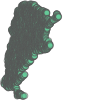

In [72]:
# this is the case of Argentina:
temporal_gdf.sample_points(size=temporal_gdf['dots_per_country'],rng=123).loc['ARGENTINA']

As usual, that GeoS is turned into a GeoDF:

In [73]:
SAmerica_dots=gpd.GeoDataFrame(geometry=temporal_gdf.sample_points(size=temporal_gdf['dots_per_country'],rng=123))
SAmerica_dots.head(10)

,geometry
Country,
ARGENTINA,"MULTIPOINT ((-73.30253 -50.05253), (-73.20917 ..."
BOLIVIA,"MULTIPOINT ((-69.38526 -15.71373), (-69.33342 ..."
BRAZIL,"MULTIPOINT ((-73.80329 -7.43018), (-73.79706 -..."
CHILE,"MULTIPOINT ((-109.33975 -27.0844), (-75.52923 ..."
COLOMBIA,"MULTIPOINT ((-79.02123 1.64222), (-78.84972 1...."
ECUADOR,"MULTIPOINT ((-91.59549 -0.31294), (-91.55816 -..."
GUYANA,"MULTIPOINT ((-60.3444 5.31429), (-60.25068 5.3..."
SURINAME,"MULTIPOINT ((-57.74299 3.67456), (-57.41435 4...."
PARAGUAY,"MULTIPOINT ((-62.2501 -20.57819), (-62.22244 -..."


Now you have a GDF:

In [74]:
SAmerica_dots.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 12 entries, ARGENTINA to VENEZUELA
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  12 non-null     geometry
dtypes: geometry(1)
memory usage: 492.0+ bytes


Here is our DDM:

<Axes: >

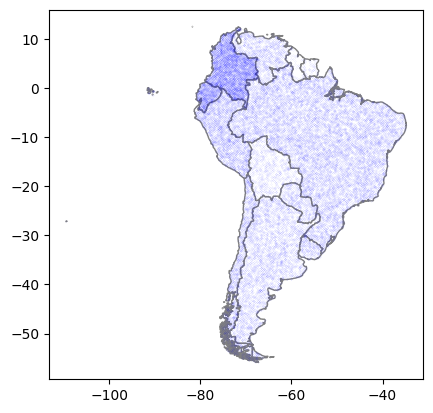

In [75]:
base=SAmerica.plot(facecolor="white",#color of polygon fill
               edgecolor='grey') #color of border
SAmerica_dots.plot(markersize=0.02, color='blue',ax=base, alpha=0.2)

It is generally recommended that DDMs use an **equal-area projection**, which benefits density and limits area distortion.

In [76]:
SAmerica_8858=SAmerica.to_crs(8858)
SAmerica_dots_8858=SAmerica_dots.to_crs(8858)

<Axes: >

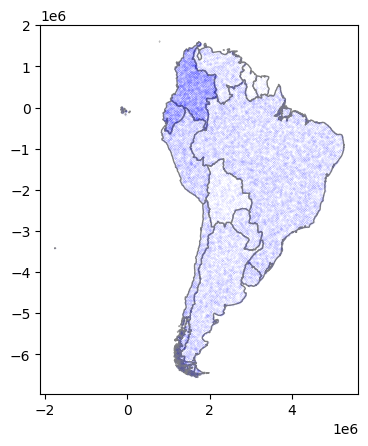

In [77]:
# new version
base=SAmerica_8858.plot(facecolor="white",
                              edgecolor='grey')
SAmerica_dots_8858.plot(markersize=0.02, color='blue',ax=base, alpha=0.2)

### Exporting to R?

SAmerica_dots_8858 has a column of multi-points as we know. Shapefiles can not deal with this structure not visual programs in R such as **leaflet**. Then, we need to split those multipoints using **explode()**:

In [78]:
SAmerica_dots_8858.explode()

,geometry
Country,
ARGENTINA,POINT (1320272.694 -5991131.856)
ARGENTINA,POINT (1334244.495 -5929037.657)
ARGENTINA,POINT (1323473.422 -6041852.991)
ARGENTINA,POINT (1323296.819 -6052128.475)
ARGENTINA,POINT (1334117.596 -6054180.308)
...,...
VENEZUELA,POINT (2840624.27 1086514.411)
VENEZUELA,POINT (2844758.229 1062519.698)
VENEZUELA,POINT (2845545.308 1036675.569)


We may just need to get rid of the indexes:

In [79]:
SAmerica_dots_8858.explode(ignore_index=True)

,geometry
0,POINT (1320272.694 -5991131.856)
1,POINT (1334244.495 -5929037.657)
2,POINT (1323473.422 -6041852.991)
3,POINT (1323296.819 -6052128.475)
4,POINT (1334117.596 -6054180.308)
...,...
24764,POINT (2840624.27 1086514.411)
24765,POINT (2844758.229 1062519.698)
24766,POINT (2845545.308 1036675.569)
24767,POINT (2847503.366 1030207.528)


This is a safe option outside Python:

In [80]:
# then
SAmerica_dots_8858=SAmerica_dots_8858.explode(ignore_index=True)

# Thematics: the PSM (Proportional Symbol Map)

You have a PSM if you use a symbol (generally a circle) to show the distribution of a variable per location.
The symbol is an aggregated raw value, and its size varies according to those values. So now we need:

### Preprocessing: scale the variable to determine size

How to adjust the size of a symbols based of mobile? We should not have symbol size five million!

In [81]:
##what about square root scaling
import numpy as np

max_size=90
min_size=1
scaled_sizes = np.sqrt(
    (SAmerica_8858.mobiles - SAmerica_8858.mobiles.min()) / (SAmerica_8858.mobiles.max() - SAmerica_8858.mobiles.min())
) * (max_size-1) + min_size

scaled_sizes.sort_values()

,mobiles
67,1.000000
116,3.228437
159,13.135092
119,18.080923
18,21.398357
47,26.447743
161,26.884171
34,32.063794
120,39.859900
7,49.053322


### Preprocessing: create new layer

Similar to DDM, the PSM is a new layer, built from the original polygons:

In [82]:
SAmerica_8858_symbols = SAmerica_8858.copy()
SAmerica_8858_symbols.set_index('Country',inplace=True)

#this is just a copy (new index names)
SAmerica_8858_symbols.head()

,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,geometry
Country,,,,,,,,,,
ARGENTINA,AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,"MULTIPOLYGON (((1647113.105 -4522341.275, 1650..."
BOLIVIA,BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,"MULTIPOLYGON (((2583278.946 -2602017.231, 2576..."
BRAZIL,BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,"MULTIPOLYGON (((1842546.07 -1275037.248, 18426..."
CHILE,CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,"MULTIPOLYGON (((1278480.113 -6148849.693, 1279..."
COLOMBIA,CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,"MULTIPOLYGON (((784973.404 1598463.703, 784294..."


Let's set the **size** of the symbol:

In [83]:
SAmerica_8858_symbols['size']=scaled_sizes.values

### Preprocessing: location for the symbol

We need one symbol per polygon, an obvious choice is the centroid.

In [84]:
# SAmerica_8858_locations will have a new geometry:
SAmerica_8858_symbols['geometry'] = SAmerica_8858_symbols['geometry'].centroid

# see the geom is NOW a POINT
SAmerica_8858_symbols

,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,geometry,size
Country,,,,,,,,,,,
ARGENTINA,AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,POINT (2194409.796 -4288179.953),49.053322
BOLIVIA,BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,POINT (2375734.977 -2125320.282),21.398357
BRAZIL,BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,POINT (3483577.922 -1340903.387),90.000000
CHILE,CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,POINT (1624096.904 -4440455.273),32.063794
COLOMBIA,CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,POINT (1618835.448 498821.163),57.845110
ECUADOR,EC,ECU,SOUTH AMERICA,71.2,36051000,283561,317,18309984,18200000,POINT (1075823.144 -183244.82),26.447743
GUYANA,GY,GUY,SOUTH AMERICA,68.2,2743000,214969,55,794099,856000,POINT (2966715.984 614595.188),1.000000
SURINAME,SR,SUR,SOUTH AMERICA,61.9,2372000,163820,55,646758,989000,POINT (3261381.757 529755.671),3.228437
PARAGUAY,PY,PRY,SOUTH AMERICA,67.0,7896000,406752,83,7522549,8670000,POINT (2907596.805 -2939102.427),18.080923


We got the basics, then:

<Axes: >

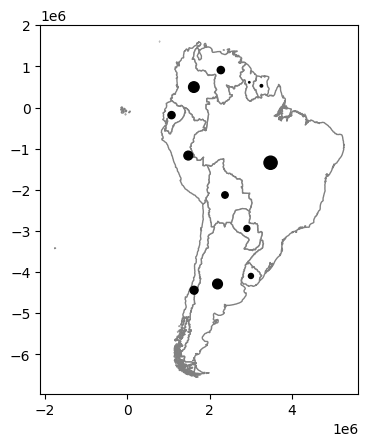

In [85]:
base=SAmerica_8858.plot(facecolor="white",
                      edgecolor='grey')
# Plot the centroids on top
SAmerica_8858_symbols.plot(
    ax=base,
    markersize=SAmerica_8858_symbols['size'],
    color='black'
)

## Exporting to R?

It is **almost** ready. R will use the new layer and the location of the points. However, R's ggplot needs NOT your size variable. Give GGPLOT the _population_ variables and use **scale_size_area()** to manage the size and the legend.

Also, notice that I have the country names as index, and the other columns might be redundant (they are in **SAmerica_8858**):

In [86]:
SAmerica_8858_symbols.head()

,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles,geometry,size
Country,,,,,,,,,,,
ARGENTINA,AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000,POINT (2194409.796 -4288179.953),49.053322
BOLIVIA,BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000,POINT (2375734.977 -2125320.282),21.398357
BRAZIL,BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000,POINT (3483577.922 -1340903.387),90.000000
CHILE,CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000,POINT (1624096.904 -4440455.273),32.063794
COLOMBIA,CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000,POINT (1618835.448 498821.163),57.845110


In [87]:
## then
SAmerica_8858_symbols.reset_index(drop=False, inplace=True)
SAmerica_8858_symbols.drop(columns=['iso2', 'iso3', 'region', 'fragility', 'co2', 'sq_km', 'num_airports','population'], inplace=True)

## final for R:
SAmerica_8858_symbols.head()

,Country,mobiles,geometry,size
0,ARGENTINA,62700000,POINT (2194409.796 -4288179.953),49.053322
1,BOLIVIA,12000000,POINT (2375734.977 -2125320.282),21.398357
2,BRAZIL,213000000,POINT (3483577.922 -1340903.387),90.000000
3,CHILE,26700000,POINT (1624096.904 -4440455.273),32.063794
4,COLOMBIA,87400000,POINT (1618835.448 498821.163),57.845110


Done!

# Thematics: Choropleths

Notice that we do not normalized DDMs nor PSMs: data is just a count or a representation of counts. Choropleths will 'paint' the whole polygon and as noticed in PSMs, we have to be very careful when using color in shape, as the area itself is a confounding. To control this visual artifact, the variable must be normalized, that is, divided by a value correlated with the area.

Then, for this course, a choropleth is a normalized representation of data.

Following our definition:

* This is **NOT** a choropleth:


### Preprocessing: Normalization

* This **IS** a choropleth:

<Axes: >

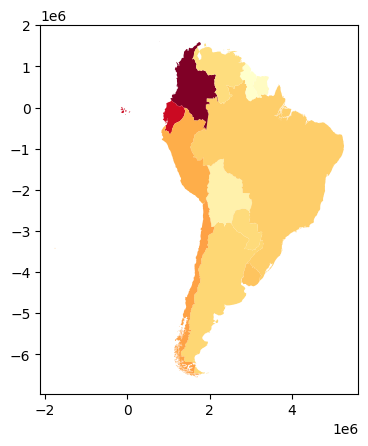

In [88]:
SAmerica_8858.plot(SAmerica_8858.mobiles/SAmerica_8858.sq_km,cmap="YlOrRd")

Choropleths are great to represent normalized indicators such as:
* Densities
* Proportion
* Ratios
* Averages

This is a density:

In [89]:
SAmerica_8858['mobiles_density']=SAmerica_8858.mobiles/SAmerica_8858.sq_km

### Preprocessing: Discretizing

Population by area is a density indicator. This is a real number (not an integer), so most of the time the color gradient might  not be that useful to reveal some pattern visually. Then, we often discretize (or bin) the indicator computed.
Now, we want to cut the variable. Run the next code to make sure you have tose packages:

In [90]:

# ! pip show numba mapclassify numpy

Let's explore the bining algorithms:

In [91]:
!pip install mapclassify folium matplotlib

In [92]:
import mapclassify
import numpy as np

np.random.seed(12345) # so we all get the same results!

# let's try 5 intervals
K=5
theVar=SAmerica_8858['mobiles_density']

# same interval width, easy interpretation
ei5 = mapclassify.EqualInterval(theVar, k=K)
# same interval width based on standard deviation, easy - but not as the previous one, poor when high skewness
msd = mapclassify.StdMean(theVar)
# interval width varies, counts per interval are close, not easy to grasp, repeated values complicate cuts
q5=mapclassify.Quantiles(theVar,k=K)

# based on similarity, good for multimodal data
mb5 = mapclassify.MaximumBreaks(theVar, k=K)
# based on similarity, good for skewed data
ht = mapclassify.HeadTailBreaks(theVar) # no K needed
# based on similarity, optimizer
fj5 = mapclassify.FisherJenks(theVar, k=K)
# based on similarity, optimizer
jc5 = mapclassify.JenksCaspall(theVar, k=K)
# based on similarity, optimizer
mp5 = mapclassify.MaxP(theVar, k=K)

How can we select the right classification?
Let me use the the Absolute deviation around class median (ADCM) to make the comparisson:

In [93]:
class5 = ei5,msd, q5,mb5,  ht, fj5, jc5, mp5
# Collect ADCM for each classifier
fits = np.array([ c.adcm for c in class5])
# Convert ADCM scores to a DataFrame
adcms = pd.DataFrame(fits)
# Add classifier names
adcms['classifier'] = [c.name for c in class5]
# Add column names to the ADCM
adcms.columns = ['ADCM', 'Classifier']

Now, plot the **adcms**:

<Axes: ylabel='Classifier'>

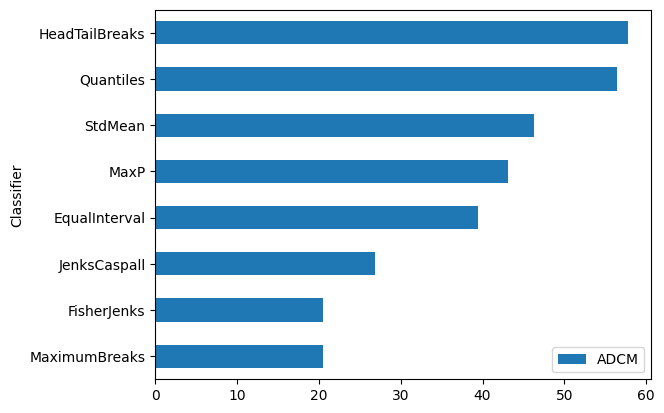

In [94]:
adcms.sort_values('ADCM').plot.barh(x='Classifier')

Let's save the best strategy:

In [95]:
SAmerica_8858['mobiles_density_MB5'] = mb5.yb # yb will give you a numeric label

In [96]:
# there you are
SAmerica_8858[['mobiles_density','mobiles_density_MB5']].head(20)

,mobiles_density,mobiles_density_MB5
7,22.550712,1
18,10.923182,0
22,25.012418,1
34,35.312696,2
37,76.740041,4
47,64.183721,3
67,3.981969,0
116,6.037114,0
119,21.315199,1
120,32.134676,2


We could create a copy of that column to add descriptive labels:

In [97]:
# renaming
newLabelsForLevels={0:"0_VeryLow", 1:"1_Low", 2:"2_Middle", 3:"3_High", 4:"4_VeryHigh"}

SAmerica_8858['mobiles_density_MB5_cat']=SAmerica_8858.loc[:,'mobiles_density_MB5'].replace(newLabelsForLevels)

# we have
SAmerica_8858[['mobiles_density','mobiles_density_MB5','mobiles_density_MB5_cat']].head(20)

,mobiles_density,mobiles_density_MB5,mobiles_density_MB5_cat
7,22.550712,1,1_Low
18,10.923182,0,0_VeryLow
22,25.012418,1,1_Low
34,35.312696,2,2_Middle
37,76.740041,4,4_VeryHigh
47,64.183721,3,3_High
67,3.981969,0,0_VeryLow
116,6.037114,0,0_VeryLow
119,21.315199,1,1_Low
120,32.134676,2,2_Middle


We are ready for a discrete choropleth:

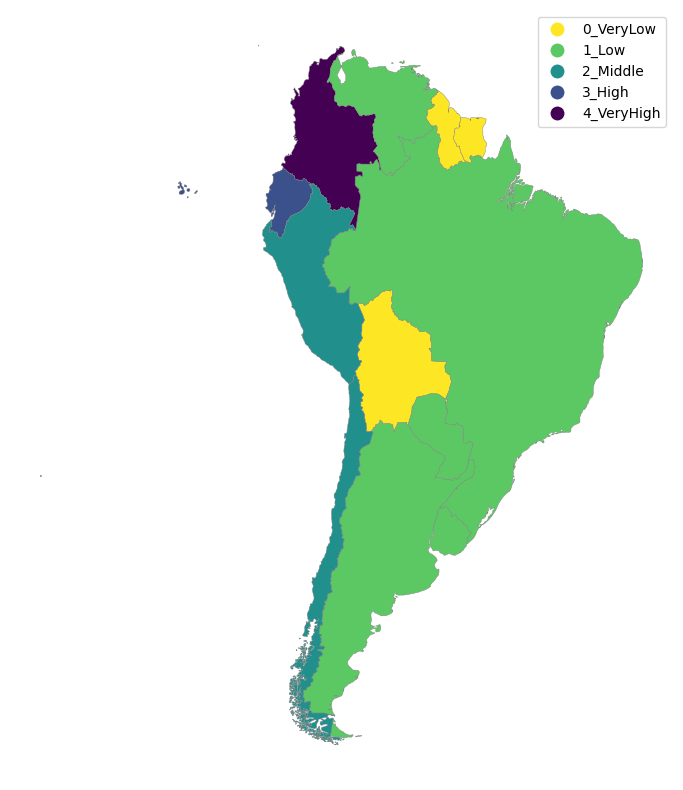

In [98]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))
SAmerica_8858.plot(column='mobiles_density_MB5_cat', # variable to plot
                 cmap='viridis_r', # set of colors
                 categorical=True, # can be interpreted as category
                 edgecolor='grey', # border color
                 linewidth=0.3, # width of border
                 legend=True, # need a legend?
                 ax=ax
       )

ax.set_axis_off()

# Saving

Let's save these maps for R.

In [99]:
## Good practice to refresh your memory

## Find only GeoDataFrames in the current session
geodataframe_list = [var for var in globals() if isinstance(globals()[var], gpd.GeoDataFrame)]

print("List of GeoDataFrames in memory:")
for name in geodataframe_list:
    print(name)

List of GeoDataFrames in memory:
countries
_3
theMapAndData
_7
SAmerica
temporal_gdf
_12
_13
SAmerica_dots
_17
SAmerica_8858
SAmerica_dots_8858
_22
_23
SAmerica_8858_symbols
_26
_28
_30
_31
_57
_63
_68
_69
_73
_78
_79
_82
_84
_86
_87


These are the ones needed in R:

In [100]:
# for choropleth and base map
SAmerica_8858.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 12 entries, 7 to 161
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Country                  12 non-null     object  
 1   iso2                     12 non-null     object  
 2   iso3                     12 non-null     object  
 3   region                   12 non-null     object  
 4   fragility                12 non-null     float64 
 5   co2                      12 non-null     int64   
 6   sq_km                    12 non-null     int32   
 7   num_airports             12 non-null     int32   
 8   population               12 non-null     int32   
 9   mobiles                  12 non-null     int32   
 10  geometry                 12 non-null     geometry
 11  mobiles_density          12 non-null     float64 
 12  mobiles_density_MB5      12 non-null     int64   
 13  mobiles_density_MB5_cat  12 non-null     object  
dtypes: float

In [101]:
# for DDMs
SAmerica_dots_8858.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 24769 entries, 0 to 24768
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  24769 non-null  geometry
dtypes: geometry(1)
memory usage: 193.6 KB


In [102]:
# for PSMs
SAmerica_8858_symbols.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Country   12 non-null     object  
 1   mobiles   12 non-null     int32   
 2   geometry  12 non-null     geometry
 3   size      12 non-null     float64 
dtypes: float64(1), geometry(1), int32(1), object(1)
memory usage: 468.0+ bytes


The file **SAmerica_8858.gpkg** will keep all those maps as layers!

In [103]:
SAmerica_8858.to_file("SAmerica_8858.gpkg",driver='GPKG',layer='continent')
SAmerica_dots_8858.to_file("SAmerica_8858.gpkg",driver='GPKG',layer='mobiles_ddm')
SAmerica_8858_symbols.to_file("SAmerica_8858.gpkg",driver='GPKG',layer='mobiles_psm')


from google.colab import files
files.download("/content/SAmerica_8858.gpkg")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Take a look at the [Dashboard](https://dacss-spatial.github.io/The-Thematics/draft_storyboard_tabs.html)